In [1]:
# pandas_datareader is not required: DGS3MO is pulled directly from FRED via
# requests (see the data-loading cell).


In [2]:
pip install -U openai


Note: you may need to restart the kernel to use updated packages.


In [3]:

import os, getpass

OPENAI_API_KEY = ""

if (not OPENAI_API_KEY) or OPENAI_API_KEY == "PASTE_KEY_HERE":
    if os.environ.get("OPENAI_API_KEY"):
        OPENAI_API_KEY = os.environ["OPENAI_API_KEY"]
    else:
        OPENAI_API_KEY = getpass.getpass("OpenAI API key (sk-...): ")

OPENAI_API_KEY = (OPENAI_API_KEY or "").strip()

if OPENAI_API_KEY == "PASTE_KEY_HERE" or len(OPENAI_API_KEY) == 17:
    raise ValueError("Placeholder key (17 chars). Replace it with a valid key (sk-...).")
if not OPENAI_API_KEY.startswith("sk-") or len(OPENAI_API_KEY) < 40:
    raise ValueError(f"Invalid key: {len(OPENAI_API_KEY)} chars and/or not starting with 'sk-'.")

os.environ["OPENAI_API_KEY"] = OPENAI_API_KEY
print(f"OPENAI_API_KEY loaded: starts with {OPENAI_API_KEY[:7]}..., length {len(OPENAI_API_KEY)} chars")


OPENAI_API_KEY loaded: starts with sk-proj..., length 164 chars


In [4]:
# OpenAI client and a robust chat wrapper (shared by the analyst and the
# advisor). A pinned model snapshot is used for reproducibility; if your
# account does not have this snapshot, switch OPENAI_MODEL back to "gpt-4o-mini".
import os, json, time
from openai import OpenAI

OPENAI_MODEL = "gpt-4o-mini-2024-07-18"
client = OpenAI(api_key=os.environ["OPENAI_API_KEY"])

def _chat(messages, json_mode=False, temperature=0.0, seed=None, max_retries=3):
    kwargs = dict(model=OPENAI_MODEL, messages=messages)
    if json_mode:
        kwargs["response_format"] = {"type": "json_object"}
    if seed is not None:
        kwargs["seed"] = seed
    last_err = None
    for attempt in range(max_retries):
        try:
            try:
                return client.chat.completions.create(temperature=temperature, **kwargs)
            except Exception:
                return client.chat.completions.create(**kwargs)
        except Exception as e:
            last_err = e
            time.sleep(1.5 * (attempt + 1))
    raise RuntimeError(f"OpenAI call failed after {max_retries} attempts: {last_err}")


In [5]:
import pandas as pd
import numpy as np
from arch import arch_model
from scipy.stats import kurtosis
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import requests, io, time, os

# Load data.
file_path = "dadostrabalho_ate_dez2025.xlsx"
df = pd.read_excel(file_path)

# Strip column names.
df.columns = df.columns.map(lambda c: str(c).strip())

# Drop the proxy components from the asset universe. RevOliveOil = POLVOILUSDM
# (price) x prod_EU27 (production); neither is an investable asset, so both are
# excluded from the screening funnel and the optimisation.
aux_cols = ["POLVOILUSDM", "prod_EU27"]
df = df.drop(columns=[c for c in aux_cols if c in df.columns]).reset_index(drop=True).copy()

# Identify the last data date.
date_col = df.columns[0]
df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
last_data_date = df[date_col].dropna().max()
if pd.isna(last_data_date):
    raise ValueError("Could not identify the last data date.")
print(f"Sample: {df[date_col].min().date()} -> {last_data_date.date()}  ({len(df)} months)")

# Risk-free rate aligned to the last data date. DGS3MO is the Treasury 3-month
# constant-maturity rate (annual %); the last observation up to the sample end
# is used, not the current rate, so the pipeline works with any dataset.
def fetch_dgs3mo(end_date, attempts=4, timeout=30, fred_api_key=None):
    coed = end_date.strftime("%Y-%m-%d")
    cosd = (end_date - pd.Timedelta(days=370)).strftime("%Y-%m-%d")
    headers = {"User-Agent": "Mozilla/5.0 (research notebook)"}
    fred_api_key = fred_api_key or os.environ.get("FRED_API_KEY")

    # 1) Official FRED API (most reliable for scripts; requires a free key).
    if fred_api_key:
        for t in range(attempts):
            try:
                r = requests.get("https://api.stlouisfed.org/fred/series/observations",
                                 params={"series_id": "DGS3MO", "api_key": fred_api_key,
                                         "file_type": "json", "observation_start": cosd,
                                         "observation_end": coed, "sort_order": "asc"},
                                 headers=headers, timeout=timeout)
                r.raise_for_status()
                obs = [o for o in r.json().get("observations", [])
                       if o.get("value") not in (".", "", None)]
                if obs:
                    idx = pd.to_datetime([o["date"] for o in obs])
                    val = [float(o["value"]) for o in obs]
                    return pd.DataFrame({"DGS3MO": val}, index=idx)
            except Exception as e:
                print(f"[FRED api] attempt {t+1}/{attempts} failed: {e}")
                time.sleep(2 * (t + 1))

    # 2) US Treasury daily rates (same 3M series, no key, different host).
    for yr in (end_date.year, end_date.year - 1):
        try:
            url = ("https://home.treasury.gov/resource-center/data-chart-center/"
                   f"interest-rates/daily-treasury-rates.csv/{yr}/all"
                   f"?type=daily_treasury_yield_curve&field_tdr_date_value={yr}&_format=csv")
            r = requests.get(url, headers=headers, timeout=timeout)
            r.raise_for_status()
            tb = pd.read_csv(io.StringIO(r.text))
            dcol = next(c for c in tb.columns if c.strip().lower() == "date")
            c3   = next(c for c in tb.columns if c.strip().lower().startswith("3 mo"))
            tb[dcol] = pd.to_datetime(tb[dcol])
            tb = tb[[dcol, c3]].dropna().set_index(dcol).sort_index()
            tb = tb[tb.index <= end_date]
            if not tb.empty:
                return tb.rename(columns={c3: "DGS3MO"})
        except Exception as e:
            print(f"[Treasury {yr}] failed: {e}")

    # 3) Public FRED CSV (fredgraph) as a last resort.
    for t in range(attempts):
        try:
            r = requests.get("https://fred.stlouisfed.org/graph/fredgraph.csv",
                             params={"id": "DGS3MO", "cosd": cosd, "coed": coed},
                             headers=headers, timeout=timeout)
            r.raise_for_status()
            s = pd.read_csv(io.StringIO(r.text), index_col=0,
                            parse_dates=True, na_values=".").dropna()
            if not s.empty:
                return s
        except Exception as e:
            print(f"[FRED csv] attempt {t+1}/{attempts} failed: {e}")
            time.sleep(2 * (t + 1))

    return None

# Optional free FRED key (most reliable path). Leave "" to try without a key.
FRED_API_KEY = ""
if FRED_API_KEY:
    os.environ["FRED_API_KEY"] = FRED_API_KEY

dgs3mo = fetch_dgs3mo(last_data_date)

# No hardcoded value: the rate is always pulled from FRED and aligned to the
# sample, so the pipeline works with any dataset and any end date.
if dgs3mo is None or dgs3mo.empty:
    raise RuntimeError(
        "Could not fetch DGS3MO from FRED. The rate is always pulled from FRED "
        "and aligned to the last sample date (no hardcoded value). Check the "
        "connection to fred.stlouisfed.org, or set a free key "
        "(os.environ['FRED_API_KEY'] = '...') and rerun."
    )

rf_date_used = dgs3mo.index[-1]
rf_annual = float(dgs3mo.iloc[-1, 0]) / 100  # % -> decimal

# Effective monthly rate.
rf_monthly = (1 + rf_annual)**(1/12) - 1

print(f"Risk-free (DGS3MO) used: {rf_annual:.4%} annual on {rf_date_used.date()}")
print(f"Equivalent monthly risk-free: {rf_monthly:.4%}")

# Volatility penalty.
vol_penalty = 100.0

# Force prices to numeric.
df.iloc[:, 1:] = df.iloc[:, 1:].apply(pd.to_numeric, errors="coerce")

# Average monthly price per asset.
average_monthly_prices = df.iloc[:, 1:].mean(skipna=True)
print("=== Average monthly price per asset ===")
print(average_monthly_prices)

# Monthly returns.
returns = df.iloc[:, 1:].pct_change()

# Mean and variance of monthly returns.
mean_returns = returns.mean(skipna=True)
var_returns = returns.var(skipna=True)
return_variance_table = pd.DataFrame({
    "Mean_Return_Monthly": mean_returns,
    "Variance_Return_Monthly": var_returns,
})
print("\n=== Monthly returns: mean and variance (per asset) ===")
print(return_variance_table.sort_values("Variance_Return_Monthly", ascending=True))


Sample: 2010-01-01 -> 2025-12-01  (192 months)
Risk-free (DGS3MO) used: 3.8100% annual on 2025-12-01
Equivalent monthly risk-free: 0.3121%
=== Average monthly price per asset ===
RevOliveOil                                 713832.859272
SPY                                            269.049705
EEM (iShares MSCI Emerging Markets ETF )        35.425598
EWJ                                             46.206711
EWC                                             26.566540
VGK                                             43.840682
IWM                                            132.664108
XLU                                             21.559298
XLV                                             78.552414
XLP                                             46.078138
IGF                                             34.147190
LQD                                             87.122047
QQQ                                            201.933298
EFA                                             52.858971
EMB      

In [6]:
# Monthly Sharpe ratio.
mean_return = returns.mean()
std_return = returns.std()
sharpe = (mean_return - rf_monthly) / std_return
print("\n=== Monthly Sharpe ratio (sorted) ===")
print(sharpe.sort_values(ascending=False))



=== Monthly Sharpe ratio (sorted) ===
QQQ                                         0.257785
SPY                                         0.213352
VIG                                         0.198685
XLV                                         0.188602
XLP                                         0.154308
IDU                                         0.148611
XLU                                         0.147824
XLF                                         0.147348
IWM                                         0.123967
GLD                                         0.106153
VNQ                                         0.103557
SLV                                         0.090758
IGF                                         0.086266
VGK                                         0.082090
EWC                                         0.080478
EFA                                         0.076536
HYG                                         0.070199
EWJ                                         0.069149
XLE    

In [7]:
# Correlation with the RevOliveOil revenue proxy (a more negative value is a
# better hedge).
oo_return = returns["RevOliveOil"]
correlations = returns.corrwith(oo_return).drop("RevOliveOil", errors="ignore")
print("\n=== Correlation with RevOliveOil (more negative = better hedge) ===")
print(correlations.sort_values(ascending=True))



=== Correlation with RevOliveOil (more negative = better hedge) ===
XLP                                        -0.137482
VIG                                        -0.117913
LQD                                        -0.115552
EWJ                                        -0.115438
QQQ                                        -0.110040
SPY                                        -0.105263
VNQ                                        -0.098949
XLF                                        -0.092741
EFA                                        -0.091731
VGK                                        -0.085822
TLT                                        -0.085214
IGF                                        -0.079201
IWM                                        -0.071489
EMB                                        -0.068872
BND                                        -0.063925
ICLN                                       -0.061811
EWC                                        -0.052314
HYG                           

In [8]:
# Prices excluding the date column and the olive-oil proxy.
df_ex_oo = df.drop(columns=[df.columns[0], "RevOliveOil"], errors="ignore").copy()
df_ex_oo = df_ex_oo.apply(pd.to_numeric, errors="coerce")

# Conditional volatility via GARCH(1,1).
log_returns = np.log(df_ex_oo / df_ex_oo.shift(1))
log_returns = log_returns.replace([np.inf, -np.inf], np.nan).dropna()

cond_vol = {}
for asset in log_returns.columns:
    try:
        model = arch_model(log_returns[asset] * 100, vol="Garch", p=1, q=1, rescale=False)
        res = model.fit(disp="off")
        alpha = res.params["alpha[1]"]
        beta = res.params["beta[1]"]
        if alpha + beta >= 1:
            cond_vol[asset] = vol_penalty
        else:
            cond_var = res.conditional_volatility ** 2
            final_vol = np.sqrt(cond_var.mean())
            cond_vol[asset] = final_vol
    except Exception as e:
        print(f"GARCH estimation failed for {asset}: {e}")
        cond_vol[asset] = np.nan

vol_df = pd.Series(cond_vol)
print("\n=== Final conditional volatility (GARCH(1,1)) ===")
print(vol_df.sort_values())



=== Final conditional volatility (GARCH(1,1)) ===
SHY                                           0.426748
BND                                           1.305851
TIP                                           1.465430
IEF                                           1.850123
LQD                                           2.136791
EMB                                           2.798770
XLP                                           3.488783
DBA                                           3.667355
VIG                                           3.739591
XLV                                           3.930504
TLT                                           3.946865
EWJ                                           4.100123
IDU                                           4.103884
SPY                                           4.222526
XLU                                           4.223596
GLD                                           4.521970
IGF                                           4.547360
EFA           

In [9]:
from scipy.stats import kurtosis

# Excess kurtosis per asset.
excess_kurtosis = returns.apply(lambda x: kurtosis(x.dropna(), fisher=True, bias=False))
print("\n=== Excess kurtosis per asset (low to high) ===")
print(excess_kurtosis.sort_values(ascending=True))



=== Excess kurtosis per asset (low to high) ===
XLV                                         -0.096823
GLD                                         -0.062345
IDU                                          0.107490
XLU                                          0.113405
QQQ                                          0.118197
IEF                                          0.121259
EWJ                                          0.128020
XLP                                          0.137436
VIG                                          0.342576
TLT                                          0.427355
VGK                                          0.516847
DBC                                          0.558263
DBB                                          0.631599
SPY                                          0.703007
EFA                                          0.714406
ICLN                                         0.886579
SLV                                          0.967086
DJP                              

In [10]:
# Robust min-max normalisation. Each metric is clipped to its 5th/95th
# percentiles before scaling so a single fat-tailed asset cannot stretch the
# range and crush the rest. Rank and z-score normalisation are avoided because
# they collapse cross-sectional dispersion, which the CRITIC contrast term needs.
def robust_minmax_norm(series, lo=0.05, hi=0.95):
    s = pd.to_numeric(series, errors="coerce").replace([np.inf, -np.inf], np.nan)
    ql, qh = s.quantile(lo), s.quantile(hi)
    if pd.isna(ql) or pd.isna(qh) or qh == ql:
        return pd.Series(0.5, index=s.index)
    s = s.clip(ql, qh)
    return ((s - ql) / (qh - ql)).fillna(0.0)

def reversed_robust_minmax_norm(series, lo=0.05, hi=0.95):
    return 1.0 - robust_minmax_norm(series, lo=lo, hi=hi)

# Sharpe: higher is better.
sharpe_norm = robust_minmax_norm(sharpe)
# Correlation with the olive-oil proxy: lower is better.
corr_norm = reversed_robust_minmax_norm(correlations)
# Conditional GARCH volatility: lower is better.
vol_norm = reversed_robust_minmax_norm(vol_df)
# Excess kurtosis: lower is better.
kurtosis_norm = reversed_robust_minmax_norm(excess_kurtosis)

# The olive-oil proxy is the benchmark, not a candidate asset, so drop it.
for s in [sharpe_norm, corr_norm, vol_norm, kurtosis_norm]:
    s.drop("RevOliveOil", errors="ignore", inplace=True)

results = pd.DataFrame({
    "Sharpe_Norm": sharpe_norm,
    "Corr_Norm": corr_norm,
    "Vol_Norm": vol_norm,
    "Kurtosis_Norm": kurtosis_norm,
})
print(results)


                                          Sharpe_Norm  Corr_Norm  Vol_Norm  \
SPY                                          1.000000   0.933878  0.643590   
EEM (iShares MSCI Emerging Markets ETF )     0.349081   0.350700  0.519465   
EWJ                                          0.482751   0.995719  0.659187   
EWC                                          0.526985   0.612070  0.529205   
VGK                                          0.533279   0.815724  0.496159   
IWM                                          0.696795   0.728608  0.441270   
XLU                                          0.789948   0.344218  0.643454   
XLV                                          0.949173   0.503737  0.680801   
XLP                                          0.815268   1.000000  0.737088   
IGF                                          0.549584   0.775481  0.602197   
LQD                                          0.276192   0.996413  0.909367   
QQQ                                          1.000000   0.962911

In [11]:
import numpy as np
import pandas as pd

metric_cols = ["Sharpe_Norm", "Corr_Norm", "Vol_Norm", "Kurtosis_Norm"]
X = results[metric_cols].copy()

# Standard deviation of each metric across assets.
sigma = X.std(ddof=1)
# Correlation matrix between metrics.
R = X.corr()
# Information content: C_j = sigma_j * sum_k (1 - r_jk).
C = sigma * (1 - R).sum(axis=1)
# CRITIC weights.
w_critic = C / C.sum()

print("=== sigma ===")
print(sigma)
print("\n=== Correlation matrix R ===")
print(R)
print("\n=== C (CRITIC) ===")
print(C)
print("\n=== CRITIC weights (w_critic) ===")
print(w_critic)


=== sigma ===
Sharpe_Norm      0.312817
Corr_Norm        0.321969
Vol_Norm         0.267929
Kurtosis_Norm    0.286979
dtype: float64

=== Correlation matrix R ===
               Sharpe_Norm  Corr_Norm  Vol_Norm  Kurtosis_Norm
Sharpe_Norm       1.000000   0.462233 -0.184735       0.304855
Corr_Norm         0.462233   1.000000  0.303290       0.179734
Vol_Norm         -0.184735   0.303290  1.000000       0.226217
Kurtosis_Norm     0.304855   0.179734  0.226217       1.000000

=== C (CRITIC) ===
Sharpe_Norm      0.756282
Corr_Norm        0.661565
Vol_Norm         0.711413
Kurtosis_Norm    0.656950
dtype: float64

=== CRITIC weights (w_critic) ===
Sharpe_Norm      0.271438
Corr_Norm        0.237443
Vol_Norm         0.255334
Kurtosis_Norm    0.235786
dtype: float64


In [12]:
# Shared tilt core + quantitative anchor (rule).
# make_tilt(emphasis): maps a per-criterion emphasis to a multiplicative tilt
#   with an EXACT geometric mean of 1, INSIDE the band [LO, HI]:
#     1) centre the emphasis in log space -> GM = 1;
#     2) if needed, SCALE it to fit the band (only SHRINKS, never amplifies a
#        small emphasis) -> mild regimes give mild tilts; extremes are capped.
#   This is the single normaliser used by both the rule and the AI overlay.
# rule_based_tilt: deterministic. Serves as (i) the anchor for the AI overlay,
#   (ii) the fallback if the API fails, (iii) the validation benchmark.
import numpy as np, pandas as pd
CRITERIA  = ["Sharpe_Norm", "Corr_Norm", "Vol_Norm", "Kurtosis_Norm"]
DEFENSIVE = ["Corr_Norm", "Vol_Norm", "Kurtosis_Norm"]
TILT_LO, TILT_HI = 0.60, 1.60

def _clip01(x): return float(np.clip(x, 0.0, 1.0))

def make_tilt(emphasis: dict) -> pd.Series:
    e = pd.Series(emphasis, dtype="float64").reindex(CRITERIA).fillna(0.0)
    e = e - e.mean()                                  # GM(exp(e)) = 1 exactly
    L = min(np.log(TILT_HI), -np.log(TILT_LO))        # max admissible |log|
    m = float(np.abs(e).max())
    if m > L and m > 0: e = e * (L / m)               # scale to fit (shrink only)
    return np.exp(e).reindex(CRITERIA)

def regime_stress_index(signals: dict) -> float:
    s_vix = _clip01((signals.get("vix_level", 18.0) - 12.0) / (35.0 - 12.0))  # ~12 calm / ~35 stress
    s_mom = _clip01((0.12 - signals.get("spy_6m_return", 0.0)) / 0.24)        # +12% calm / -12% stress
    s_cs  = 1.0 if signals.get("credit_spreads_trend") == "widening" else 0.0
    s_inf = 1.0 if signals.get("inflation_trend")      == "up"       else 0.0
    return _clip01(0.40*s_vix + 0.25*s_mom + 0.25*s_cs + 0.10*s_inf)

def rule_based_tilt(signals: dict) -> pd.Series:
    a = (regime_stress_index(signals) - 0.5) * 2.0    # [-1,1]: <0 calm, >0 stress
    return make_tilt({"Sharpe_Norm": -a, "Corr_Norm": +a, "Vol_Norm": +a, "Kurtosis_Norm": +a})


In [13]:
# Model-based analyst. Reads a textual briefing (macro narrative + olive-oil
# sector notes) and returns a structured assessment; the numeric signals enter
# only as context. The point is to interpret unstructured text and judge the
# left-tail risk to olive-oil revenue (drought, harvest, prices/margins,
# policy/trade). Output is validated JSON; the call is pinned, seeded and
# logged. On API failure it returns a neutral view (confidence=0) which, in the
# fusion, collapses exactly to the rule.
import json, numpy as np, pandas as pd
SEED_AI = 777

def _neutral_view():
    return {"macro_regime": "neutral", "macro_stress": 0.5, "sector_tail_risk": 0.0,
            "confidence": 0.0, "rationale": "neutral fallback (no API call)."}

def get_ai_view(briefing: str, signals: dict) -> dict:
    sys = ("You are a buy-side analyst covering global macro AND the olive-oil commodity "
           "complex. You reason ONLY from the information set provided (numeric signals + "
           "narrative). You never invent data and you state uncertainty honestly: if the "
           "briefing is thin or contradictory, lower your confidence.")
    user = f"""
INFORMATION SET (as of the analysis date).

Numeric market signals:
{json.dumps(signals, indent=2)}

Qualitative briefing (macro + olive-oil sector):
\"\"\"{briefing.strip()}\"\"\"

Assess the regime for a portfolio whose PROTECTED asset is OLIVE-OIL REVENUE, hedged by a
screened ETF universe. Return ONLY this JSON object:
{{
  "macro_regime": "risk_on" | "neutral" | "risk_off",
  "macro_stress": <float 0-1>,       // 0 = calm/risk-on, 1 = acute risk-off
  "sector_tail_risk": <float 0-1>,   // LEFT-tail risk to OLIVE-OIL revenue (drought, harvest
                                      // failure, price/margin shock, trade/policy). Higher =>
                                      // lean harder on tail protection.
  "confidence": <float 0-1>,         // how strongly the briefing supports a directional call
  "rationale": "<1-3 sentences>"
}}
"""
    try:
        resp = _chat([{"role": "system", "content": sys},
                      {"role": "user", "content": user}],
                     json_mode=True, temperature=0.0, seed=SEED_AI)
        raw  = resp.choices[0].message.content
        d    = json.loads(raw)
        view = {"macro_regime": str(d.get("macro_regime", "neutral")),
                "macro_stress": _clip01(d.get("macro_stress", 0.5)),
                "sector_tail_risk": _clip01(d.get("sector_tail_risk", 0.0)),
                "confidence": _clip01(d.get("confidence", 0.0)),
                "rationale": str(d.get("rationale", ""))}
    except Exception as e:
        print(f"[analyst] API unavailable -> neutral view / rule fallback ({e})")
        return _neutral_view()

    global AI_VIEW_LOG
    AI_VIEW_LOG = {"model": getattr(resp, "model", OPENAI_MODEL),
                   "system_fingerprint": getattr(resp, "system_fingerprint", None),
                   "seed": SEED_AI, "signals": signals, "briefing": briefing,
                   "raw_response": raw, "view": view}
    print("[analyst]", {k: view[k] for k in ["macro_regime","macro_stress","sector_tail_risk","confidence"]})
    print("[analyst] rationale:", view["rationale"])
    return view


In [14]:
# Fusion -> final tilt (model anchored to the rule, gated by confidence).
#   - the rule provides the reproducible quantitative stress s_quant;
#   - the model provides the qualitative stress + the sector tail risk;
#   - the model overrides the rule only to the extent of its confidence:
#         s_macro = (1 - c) * s_quant + c * macro_stress
#     low confidence -> back to the rule; high -> follow the model;
#   - the olive-oil tail overlay (also confidence-gated) adds emphasis only to
#     the tail-protective criteria: low correlation to olive oil (Corr) and
#     thin tails (Kurtosis);
#   - make_tilt enforces the band [LO, HI] and a unit geometric mean.
BETA_SECTOR = 1.0   # weight of the sector (olive-oil) tail-risk overlay

def ai_assisted_tilt(view: dict, signals: dict, beta_sector: float = BETA_SECTOR):
    s_quant = regime_stress_index(signals)
    c       = _clip01(view.get("confidence", 0.0))
    s_macro = (1 - c) * s_quant + c * _clip01(view.get("macro_stress", 0.5))
    a       = (s_macro - 0.5) * 2.0                              # [-1,1]
    st      = c * _clip01(view.get("sector_tail_risk", 0.0))     # overlay (confidence-gated)
    emphasis = {
        "Sharpe_Norm":   -a,                                     # offensive
        "Vol_Norm":      +a,                                     # general volatility
        "Corr_Norm":     +a + beta_sector * st,                 # diversify away from olive oil
        "Kurtosis_Norm": +a + beta_sector * st,                 # thin tails in the hedge
    }
    tilt = make_tilt(emphasis)
    breakdown = {"s_quant": round(s_quant,3), "confidence": round(c,3),
                 "s_macro": round(s_macro,3), "sector_eff": round(st,3)}
    return tilt, breakdown


In [15]:
# Inputs (documented information set) + execution.
# briefing: paste the macro + olive-oil sector summary as of the analysis date.
# Keep this text on file (e.g. alongside the results) so the model is
# conditioned on a reproducible information set at time t.
signals = {
    "vix_level": 18.5,
    "spy_6m_return": 0.09,
    "us10y_trend": "up",
    "inflation_trend": "down",
    "credit_spreads_trend": "tightening"
}

briefing = """
Macro: equities firm over the last six months; credit spreads tightening; the Fed on hold
with inflation cooling. No acute systemic stress in the data, though positioning looks crowded.
Olive-oil sector: Iberian (Spain/Portugal) rainfall has improved versus the prior drought year,
pointing to a partial harvest recovery and an easing of the recent price spike; however,
soil-moisture deficits persist in parts of Andalusia and input costs remain elevated, so
producer margins are still fragile.
""".strip()

ai_view            = get_ai_view(briefing, signals)
tilt_ai, breakdown = ai_assisted_tilt(ai_view, signals)
tilt_rule          = rule_based_tilt(signals)

comparison = pd.DataFrame({"AI": tilt_ai, "Rule(anchor)": tilt_rule}).reindex(CRITERIA).round(4)
print("\nFusion:", breakdown)
print("\nTilt (AI vs rule anchor):")
print(comparison.to_string())

# Source of the tilt: True = model-based tilt; False = deterministic rule.
USE_AI_TILT = True
tilt = tilt_ai if USE_AI_TILT else tilt_rule
print("\nTilt in use:", "AI" if USE_AI_TILT else "RULE-BASED")


[analyst] {'macro_regime': 'risk_on', 'macro_stress': 0.2, 'sector_tail_risk': 0.4, 'confidence': 0.6}
[analyst] rationale: The macro environment shows firm equities, tightening credit spreads, and cooling inflation, indicating a risk-on sentiment. However, the olive-oil sector faces some challenges with soil-moisture deficits and elevated input costs, which contribute to moderate tail risk for revenue.

Fusion: {'s_quant': 0.144, 'confidence': 0.6, 's_macro': 0.178, 'sector_eff': 0.24}

Tilt (AI vs rule anchor):
                   AI  Rule(anchor)
Sharpe_Norm    1.6000         1.600
Corr_Norm      0.8938         0.855
Vol_Norm       0.7823         0.855
Kurtosis_Norm  0.8938         0.855

Tilt in use: AI


In [16]:
# Deterministic check of the mechanism (no API). Feeds the fusion with synthetic
# views instead of the model, to show in a reproducible way that the system
# responds in the right economic direction:
#   - high macro risk          -> Sharpe falls, defensives rise;
#   - high olive-oil tail risk -> Corr and Kurtosis rise more (protection);
#   - low confidence           -> collapses back to the rule.
demo_signals = dict(signals)   # same anchor s_quant
views_demo = {
    "calm / low sector": {"macro_stress": 0.15, "sector_tail_risk": 0.05, "confidence": 0.8},
    "neutral":           {"macro_stress": 0.50, "sector_tail_risk": 0.20, "confidence": 0.8},
    "risk-off macro":    {"macro_stress": 0.85, "sector_tail_risk": 0.20, "confidence": 0.8},
    "olive tail shock":  {"macro_stress": 0.50, "sector_tail_risk": 0.90, "confidence": 0.8},
    "low AI confidence": {"macro_stress": 0.90, "sector_tail_risk": 0.90, "confidence": 0.1},
}
rows = []
for name, v in views_demo.items():
    t, bd = ai_assisted_tilt(v, demo_signals)
    rows.append({"scenario": name, "s_macro": bd["s_macro"], "sector_eff": bd["sector_eff"],
                 **{c: round(float(t[c]),3) for c in CRITERIA}})
print("=== Final-tilt sensitivity (synthetic views, deterministic) ===")
print(pd.DataFrame(rows).set_index("scenario").to_string())


=== Final-tilt sensitivity (synthetic views, deterministic) ===
                   s_macro  sector_eff  Sharpe_Norm  Corr_Norm  Vol_Norm  Kurtosis_Norm
scenario                                                                               
calm / low sector    0.149        0.04        1.600      0.860     0.845          0.860
neutral              0.429        0.16        1.143      1.009     0.860          1.009
risk-off macro       0.709        0.16        0.625      1.212     1.089          1.212
olive tail shock     0.429        0.72        0.864      1.335     0.650          1.335
low AI confidence    0.220        0.09        1.600      0.870     0.825          0.870


In [17]:
# Final criterion weights = CRITIC x tilt, renormalised.
w_raw = w_critic * tilt.reindex(w_critic.index)
w_criteria = w_raw / w_raw.sum()
print("Criterion weights (CRITIC x tilt):\n", w_criteria.round(4).to_string())


Criterion weights (CRITIC x tilt):
 Sharpe_Norm      0.4109
Corr_Norm        0.2008
Vol_Norm         0.1890
Kurtosis_Norm    0.1994


In [18]:
metric_cols = ["Sharpe_Norm", "Corr_Norm", "Vol_Norm", "Kurtosis_Norm"]
w = w_criteria.reindex(metric_cols)
results["Final_Score"] = (results[metric_cols] * w).sum(axis=1)
top_n = 10
top = results.sort_values("Final_Score", ascending=False).head(top_n)
print(f"=== TOP {top_n} ===")
print(top[metric_cols + ["Final_Score"]])


=== TOP 10 ===
     Sharpe_Norm  Corr_Norm  Vol_Norm  Kurtosis_Norm  Final_Score
VIG     0.988546   1.000000  0.705128       0.944306     0.928465
QQQ     1.000000   0.962911  0.547128       0.990752     0.905126
SPY     1.000000   0.933878  0.643590       0.869696     0.893391
XLP     0.815268   1.000000  0.737088       0.986770     0.871777
XLV     0.949173   0.503737  0.680801       1.000000     0.819157
XLF     0.788090   0.857774  0.483398       0.736218     0.734158
IDU     0.793024   0.394602  0.658708       0.992969     0.727511
EWJ     0.482751   0.995719  0.659187       0.988719     0.719964
XLU     0.789948   0.344218  0.643454       0.991744     0.713005
VNQ     0.617101   0.895506  0.503584       0.783818     0.684785


Markowitz assets: ['VIG', 'QQQ', 'SPY', 'XLP', 'XLV', 'XLF', 'IDU', 'EWJ', 'XLU', 'VNQ', 'RevOliveOil']


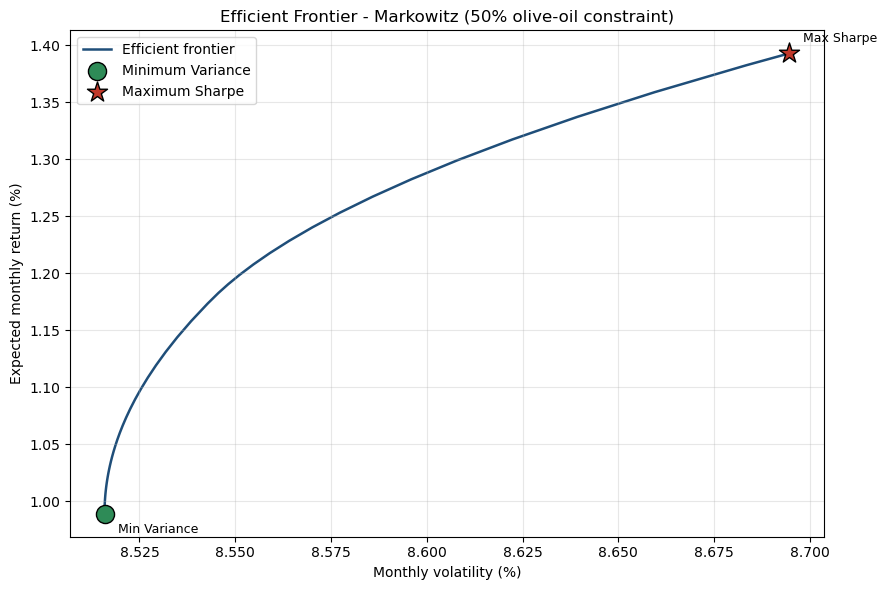


=== Metrics (Min Variance / Max Sharpe) ===
              Exp_Return_Monthly  Vol_Monthly  Sharpe_Monthly
Min Variance            0.009891     0.085159        0.079501
Max Sharpe              0.013930     0.086947        0.124321

=== Weights (RevOliveOil = 50%) ===
             Min Variance Weights  Max Sharpe Weights
VIG                        0.0000                 0.0
QQQ                        0.0166                 0.5
SPY                        0.0000                 0.0
XLP                        0.3197                 0.0
XLV                        0.0000                 0.0
XLF                        0.0000                 0.0
IDU                        0.0000                 0.0
EWJ                        0.1637                 0.0
XLU                        0.0000                 0.0
VNQ                        0.0000                 0.0
RevOliveOil                0.5000                 0.5


In [19]:
# Markowitz efficient frontier with a fixed 50% olive-oil allocation
# (Minimum Variance and Maximum Sharpe; the other assets are long-only and sum
# to 50%). Produces metrics, weights, weights_mkv and rets_mkv for the risk stage.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# 1) Asset selection (top N of the funnel + olive oil).
top_assets = results.sort_values("Final_Score", ascending=False).head(top_n).index.tolist()
assets = top_assets + (["RevOliveOil"] if "RevOliveOil" not in top_assets else [])
print("Markowitz assets:", assets)

# 2) Returns.
df2 = df.copy()
df2.columns = df2.columns.map(lambda c: str(c).strip())
try:
    df2.iloc[:, 0] = pd.to_datetime(df2.iloc[:, 0])
    df2 = df2.set_index(df2.columns[0])
except Exception:
    pass

prices = df2[assets].apply(pd.to_numeric, errors="coerce")
rets = prices.pct_change(fill_method=None).dropna(axis=0, how="any")

mu    = rets.mean().values
Sigma = rets.cov().values
names = list(rets.columns)
n     = len(names)

idx_oo    = names.index("RevOliveOil")
idx_other = [i for i in range(n) if i != idx_oo]
m         = len(idx_other)
rf        = float(rf_monthly)

# 3) Project Sigma to PSD (stabilises the solver).
def make_psd(A, eps=1e-10):
    A = 0.5 * (A + A.T)
    vals, vecs = np.linalg.eigh(A)
    vals = np.maximum(vals, eps)
    return vecs @ np.diag(vals) @ vecs.T

Sigma_psd = make_psd(Sigma)

# 4) Helpers (50% fixed in olive oil).
def pack_full_weights(w_other):
    w = np.zeros(n)
    w[idx_oo] = 0.50
    w[idx_other] = w_other
    return w

def port_stats(w_other):
    w = pack_full_weights(w_other)
    pret = float(w @ mu)
    pvol = float(np.sqrt(w @ Sigma_psd @ w))
    psh  = (pret - rf) / pvol if pvol > 0 else np.nan
    return pret, pvol, psh, w

cons_sum = ({"type": "eq", "fun": lambda w_other: np.sum(w_other) - 0.50},)
bounds   = [(0.0, 0.50) for _ in range(m)]
w0       = np.array([0.50 / m] * m)

# 5) Minimum Variance and Maximum Sharpe.
def obj_min_var(w_other):
    w = pack_full_weights(w_other)
    return float(w @ Sigma_psd @ w)

def obj_neg_sharpe(w_other):
    return -port_stats(w_other)[2]

res_minv = minimize(obj_min_var, w0, method="SLSQP", bounds=bounds,
                    constraints=cons_sum, options={"ftol": 1e-12, "maxiter": 2000})
if not res_minv.success:
    raise RuntimeError(f"Minimum Variance failed: {res_minv.message}")
ret_minv, vol_minv, sharpe_minv, w_minv = port_stats(res_minv.x)

res_maxs = minimize(obj_neg_sharpe, res_minv.x, method="SLSQP", bounds=bounds,
                    constraints=cons_sum, options={"ftol": 1e-12, "maxiter": 2000})
if not res_maxs.success:
    raise RuntimeError(f"Maximum Sharpe failed: {res_maxs.message}")
ret_maxs, vol_maxs, sharpe_maxs, w_maxs = port_stats(res_maxs.x)

# 6) Efficient frontier (lambda sweep with warm start).
def obj_lambda(w_other, lam):
    w = pack_full_weights(w_other)
    return 0.5 * float(w @ Sigma_psd @ w) - lam * float(w @ mu)

front = []
w_start = res_minv.x.copy()
for lam in np.logspace(-3, 3, 160):
    r = minimize(lambda x: obj_lambda(x, lam), w_start, method="SLSQP",
                 bounds=bounds, constraints=cons_sum,
                 options={"ftol": 1e-12, "maxiter": 2000})
    if r.success:
        pret, pvol, _, _ = port_stats(r.x)
        front.append((pvol, pret))
        w_start = r.x
front = pd.DataFrame(front, columns=["vol", "ret"]).sort_values("vol").drop_duplicates()

# Upper envelope (remove dominated points).
best, max_ret = [], -np.inf
for _, row in front.iterrows():
    if row["ret"] > max_ret + 1e-12:
        best.append(row); max_ret = row["ret"]
best = pd.DataFrame(best)

# 7) Efficient-frontier plot.
plt.figure(figsize=(9, 6))
plt.plot(best["vol"] * 100, best["ret"] * 100, "-", lw=1.8,
         color="#1f4e79", label="Efficient frontier", zorder=1)
plt.scatter(vol_minv * 100, ret_minv * 100, s=170, marker="o",
            color="#2e8b57", edgecolor="black", zorder=3, label="Minimum Variance")
plt.scatter(vol_maxs * 100, ret_maxs * 100, s=230, marker="*",
            color="#c0392b", edgecolor="black", zorder=3, label="Maximum Sharpe")
plt.annotate("Min Variance", (vol_minv * 100, ret_minv * 100),
             textcoords="offset points", xytext=(10, -14), fontsize=9)
plt.annotate("Max Sharpe", (vol_maxs * 100, ret_maxs * 100),
             textcoords="offset points", xytext=(10, 8), fontsize=9)
plt.xlabel("Monthly volatility (%)")
plt.ylabel("Expected monthly return (%)")
plt.title("Efficient Frontier - Markowitz (50% olive-oil constraint)")
plt.grid(True, alpha=0.3)
plt.legend(loc="best")
plt.tight_layout()
plt.show()

# 8) Metric and weight tables.
metrics = pd.DataFrame({
    "Exp_Return_Monthly": [ret_minv, ret_maxs],
    "Vol_Monthly":        [vol_minv, vol_maxs],
    "Sharpe_Monthly":     [sharpe_minv, sharpe_maxs],
}, index=["Min Variance", "Max Sharpe"])

weights = pd.DataFrame({
    "Min Variance Weights": pd.Series(w_minv, index=names),
    "Max Sharpe Weights":   pd.Series(w_maxs, index=names),
})

print("\n=== Metrics (Min Variance / Max Sharpe) ===")
print(metrics)
print("\n=== Weights (RevOliveOil = 50%) ===")
print(weights.round(4))

weights_mkv = weights.copy()
rets_mkv    = rets.copy()


In [20]:
# Risk stage: Merton Jump-Diffusion engine (one consistent source). A single
# simulation (common random numbers) is used both to optimise and to report all
# portfolios, removing the in-sample / out-of-sample mismatch.
import numpy as np, pandas as pd
from scipy.optimize import differential_evolution
import matplotlib.pyplot as plt
from IPython.display import display

ALPHA   = 0.05
N_SIM   = 50_000
SEED_SIM = 777
JUMP_LAMBDA, JUMP_KAPPA, JUMP_DELTA = 0.10, -0.02, 0.05
OO_FIX  = 0.50

# Risk-stage universe (olive oil first).
if "top_assets" not in globals():
    top_assets = results.sort_values("Final_Score", ascending=False).head(top_n).index.tolist()
risk_assets = ["RevOliveOil"] + [a for a in top_assets if a != "RevOliveOil"]

_df = df.copy()
_df.columns = _df.columns.map(lambda c: str(c).strip())
rets_risk = (_df[risk_assets].apply(pd.to_numeric, errors="coerce")
                            .pct_change(fill_method=None).dropna(how="any"))
cols_risk = list(rets_risk.columns)

# Calibrate the jump parameters from the data.
def calibrate_mjd(returns_simple, k=3.0):
    rl = np.log1p(returns_simple.dropna(how="any"))
    T, na = rl.shape
    lam = np.zeros(na); kap = np.zeros(na); dlt = np.zeros(na)
    m_d = np.zeros(na); s_d = np.zeros(na)
    pool, rows = [], []
    for j, col in enumerate(rl.columns):
        x   = rl[col].values
        med = np.median(x)
        mad = np.median(np.abs(x - med)) * 1.4826
        sig = mad if mad > 0 else x.std(ddof=1)
        is_jump = np.abs(x - med) > k * sig
        x_d, x_j = x[~is_jump], x[is_jump]
        m_d[j] = x_d.mean()
        s_d[j] = x_d.std(ddof=1) if x_d.size > 1 else x.std(ddof=1)
        lam[j] = is_jump.sum() / T
        exc    = x_j - m_d[j]
        if exc.size >= 1: kap[j] = exc.mean(); pool += exc.tolist()
        if exc.size >= 2: dlt[j] = exc.std(ddof=1)
        rows.append((col, int(is_jump.sum()), lam[j], m_d[j], s_d[j], kap[j], dlt[j]))
    pool = np.array(pool)
    kap_p = pool.mean()      if pool.size  else JUMP_KAPPA
    dlt_p = pool.std(ddof=1) if pool.size>1 else JUMP_DELTA
    lam_f = max(lam.mean(), 1e-4)
    for j in range(na):
        if lam[j] <= 0: lam[j] = lam_f
        if kap[j] == 0: kap[j] = kap_p
        if dlt[j] == 0: dlt[j] = dlt_p
    tab = pd.DataFrame(rows, columns=["asset","n_jumps","lambda","m_diff",
                                      "s_diff","kappa","delta"]).set_index("asset")
    return m_d, s_d, lam, kap, dlt, tab

m_diff, s_diff, lam_vec, kappa_vec, delta_vec, calib_table = calibrate_mjd(rets_risk, k=3.0)
print("\n=== Calibrated MJD parameters (per asset) ===")
display(calib_table.round(4))

def simulate_mjd(returns_simple, n_sim, seed,
                 m=None, s=None, lam=None, kap=None, dlt=None, compensate=True):
    m   = m_diff    if m   is None else m
    s   = s_diff    if s   is None else s
    lam = lam_vec   if lam is None else lam
    kap = kappa_vec if kap is None else kap
    dlt = delta_vec if dlt is None else dlt
    rng = np.random.default_rng(seed)
    na  = returns_simple.shape[1]
    Z   = rng.normal(size=(na, n_sim))
    eps = rng.normal(size=(na, n_sim))
    N   = rng.poisson(lam[:, None], size=(na, n_sim))
    comp = (lam * (np.exp(kap + 0.5*dlt**2) - 1.0))[:, None] if compensate else 0.0
    r_log = (m[:, None] - comp) + s[:, None]*Z + (kap[:, None]*N + dlt[:, None]*np.sqrt(N)*eps)
    return np.expm1(r_log)

SIM = simulate_mjd(rets_risk, N_SIM, SEED_SIM)

def var_cvar(w, sim=SIM, alpha=ALPHA):
    port = np.asarray(w, float) @ sim
    var  = float(np.percentile(port, alpha * 100))
    cvar = float(port[port <= var].mean())
    return var, cvar, port

def pack_weights(weights_other):
    wo = np.clip(np.asarray(weights_other, float), 0.0, None)
    wo = wo / wo.sum() if wo.sum() > 0 else np.ones_like(wo) / len(wo)
    return np.concatenate(([OO_FIX], (1.0 - OO_FIX) * wo))

NDIM = len(cols_risk) - 1
print("Risk universe (olive oil first):", cols_risk)
print("SIM:", SIM.shape)



=== Calibrated MJD parameters (per asset) ===


,n_jumps,lambda,m_diff,s_diff,kappa,delta
asset,,,,,,
RevOliveOil,22,0.1152,0.0008,0.0360,0.0045,0.4071
VIG,4,0.0209,0.0121,0.0348,-0.1072,0.0082
QQQ,1,0.0052,0.0155,0.0484,-0.1604,0.0000
SPY,6,0.0314,0.0136,0.0372,-0.0790,0.0953
XLP,2,0.0105,0.0090,0.0335,-0.1059,0.0079
XLV,0,0.0000,0.0098,0.0394,0.0000,0.0000
XLF,3,0.0157,0.0124,0.0503,-0.1770,0.0693
IDU,4,0.0209,0.0108,0.0376,-0.1192,0.0113
EWJ,1,0.0052,0.0057,0.0403,-0.1166,0.0000


Risk universe (olive oil first): ['RevOliveOil', 'VIG', 'QQQ', 'SPY', 'XLP', 'XLV', 'XLF', 'IDU', 'EWJ', 'XLU', 'VNQ']
SIM: (11, 50000)


In [21]:
# Markowitz (Min Var / Max Sharpe) evaluated on the same MJD simulation.
_wm = weights_mkv.copy()
_wm.index = _wm.index.map(lambda c: str(c).strip())
w_minv_risk = _wm["Min Variance Weights"].reindex(cols_risk).fillna(0.0).values
w_maxs_risk = _wm["Max Sharpe Weights"].reindex(cols_risk).fillna(0.0).values

var_minv, cvar_minv, _ = var_cvar(w_minv_risk)
var_maxs, cvar_maxs, _ = var_cvar(w_maxs_risk)
print("Markowitz Min Variance :  VaR %7.3f%%   CVaR %7.3f%%" % (100*var_minv, 100*cvar_minv))
print("Markowitz Max Sharpe   :  VaR %7.3f%%   CVaR %7.3f%%" % (100*var_maxs, 100*cvar_maxs))


Markowitz Min Variance :  VaR  -5.228%   CVaR -14.239%
Markowitz Max Sharpe   :  VaR  -6.338%   CVaR -14.780%


differential_evolution step 1: f(x)= 0.138581
differential_evolution step 2: f(x)= 0.138534
differential_evolution step 3: f(x)= 0.13851
differential_evolution step 4: f(x)= 0.13851
differential_evolution step 5: f(x)= 0.13851
differential_evolution step 6: f(x)= 0.13851
differential_evolution step 7: f(x)= 0.138507
differential_evolution step 8: f(x)= 0.138486
differential_evolution step 9: f(x)= 0.138457
differential_evolution step 10: f(x)= 0.13845
differential_evolution step 11: f(x)= 0.13845
differential_evolution step 12: f(x)= 0.138441
differential_evolution step 13: f(x)= 0.138441
differential_evolution step 14: f(x)= 0.138441
differential_evolution step 15: f(x)= 0.138434
differential_evolution step 16: f(x)= 0.138428
differential_evolution step 17: f(x)= 0.138428
differential_evolution step 18: f(x)= 0.138428
differential_evolution step 19: f(x)= 0.138421
differential_evolution step 20: f(x)= 0.138421
differential_evolution step 21: f(x)= 0.138421
differential_evolution step 

,Weight
RevOliveOil,50.00%
SPY,9.85%
VIG,9.68%
QQQ,8.89%
XLU,6.19%
IDU,6.06%
XLF,3.12%
XLP,3.04%
VNQ,2.60%
XLV,0.57%


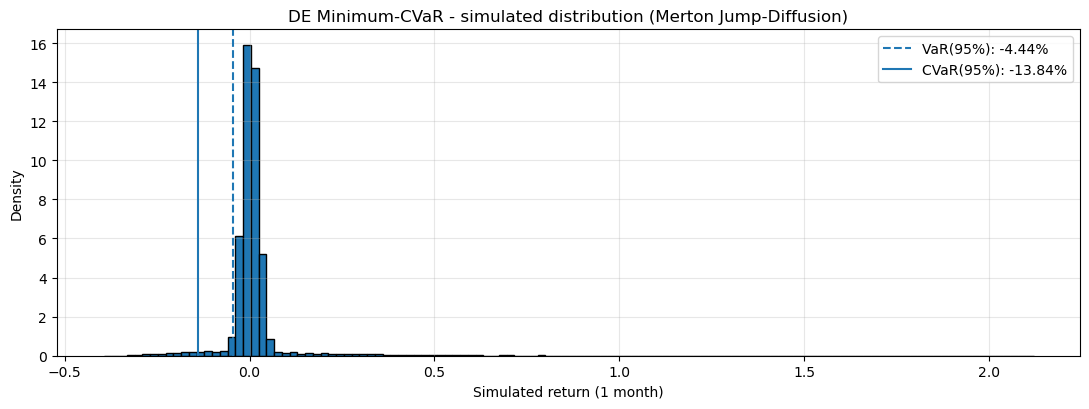

In [22]:
# Differential Evolution: minimum CVaR (smooth, coherent objective; converges well).
def _neg_cvar(weights_other):
    return -var_cvar(pack_weights(weights_other))[1]

res_cvar = differential_evolution(
    _neg_cvar, [(0.0, 1.0)] * NDIM,
    strategy="best1bin", maxiter=150, popsize=15, tol=1e-7,
    mutation=(0.5, 1.0), recombination=0.7, polish=True, seed=42, disp=True
)

w_other_cvar = res_cvar.x
w_final_cvar = pack_weights(w_other_cvar)
var_decv, cvar_decv, port_cvar = var_cvar(w_final_cvar)
print("\nDE Minimum CVaR :  VaR %7.3f%%   CVaR %7.3f%%" % (100*var_decv, 100*cvar_decv))

display(pd.Series(w_final_cvar, index=cols_risk).sort_values(ascending=False)
        .to_frame("Weight").style.format({"Weight": "{:.2%}"})
        .set_caption("DE Minimum-CVaR | weights (olive oil fixed at 50%)"))

plt.figure(figsize=(11, 4.2))
plt.hist(port_cvar, bins=120, density=True, edgecolor="black")
plt.axvline(var_decv,  linestyle="--", label=f"VaR(95%): {var_decv*100:.2f}%")
plt.axvline(cvar_decv, linestyle="-",  label=f"CVaR(95%): {cvar_decv*100:.2f}%")
plt.title("DE Minimum-CVaR - simulated distribution (Merton Jump-Diffusion)")
plt.xlabel("Simulated return (1 month)"); plt.ylabel("Density")
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()


In [23]:
# Consolidated summary: three portfolios on the same simulation (common random
# numbers). Corresponds to Section 4.2.6.
summary = pd.DataFrame({
    "Sim. VaR (95%)":  [var_minv, var_maxs, var_decv],
    "Sim. CVaR (95%)": [cvar_minv, cvar_maxs, cvar_decv],
}, index=["Markowitz - Minimum Variance", "Markowitz - Maximum Sharpe",
          "DE - Minimum CVaR"])

print("\n=== VaR / CVaR (MJD, 95%, monthly) -- all portfolios ===")
print((100*summary).round(3))

display(summary.style.format("{:.3%}")
        .highlight_max(subset=["Sim. VaR (95%)", "Sim. CVaR (95%)"], color="#d6f5d6")
        .set_caption("Merton Jump-Diffusion | VaR/CVaR of the three portfolios (same simulation)"))



=== VaR / CVaR (MJD, 95%, monthly) -- all portfolios ===
                              Sim. VaR (95%)  Sim. CVaR (95%)
Markowitz - Minimum Variance          -5.228          -14.239
Markowitz - Maximum Sharpe            -6.338          -14.780
DE - Minimum CVaR                     -4.439          -13.842


,Sim. VaR (95%),Sim. CVaR (95%)
Markowitz - Minimum Variance,-5.228%,-14.239%
Markowitz - Maximum Sharpe,-6.338%,-14.780%
DE - Minimum CVaR,-4.439%,-13.842%


In [24]:
# Interpretation layer (Sections 3.6 and 4.3). This does not change any
# numerical result; it computes comparable expected return / volatility for the
# three already-optimised portfolios, builds two summary tables, and produces a
# written interpretation of the results for a non-expert investor.
import json
import numpy as np
import pandas as pd
from IPython.display import display, Markdown

def _weights_dict(w):
    return {a: round(float(x), 4) for a, x in zip(cols_risk, np.asarray(w, dtype=float))}

def _pct(x, decimals=2):
    if x is None or pd.isna(x):
        return "n/a"
    return f"{100 * float(x):.{decimals}f}%"

def _return_and_vol(w):
    # Expected monthly return and volatility on the risk-stage returns, so the
    # DE portfolio is measured on the same basis as the Markowitz portfolios.
    w = np.asarray(w, dtype=float)
    mean_r = rets_risk[cols_risk].mean()
    cov = rets_risk[cols_risk].cov()
    exp_ret = float(np.dot(w, mean_r.values))
    vol = float(np.sqrt(w.T @ cov.values @ w))
    return round(exp_ret, 6), round(vol, 6)

de_cvar_return, de_cvar_vol = _return_and_vol(w_final_cvar)

portfolios = {
    "Markowitz Minimum Variance": {
        "expected_monthly_return": round(float(metrics.loc["Min Variance", "Exp_Return_Monthly"]), 6),
        "monthly_volatility": round(float(metrics.loc["Min Variance", "Vol_Monthly"]), 6),
        "sim_VaR_95": round(float(var_minv), 6),
        "sim_CVaR_95": round(float(cvar_minv), 6),
        "weights": _weights_dict(w_minv_risk),
    },
    "Markowitz Maximum Sharpe": {
        "expected_monthly_return": round(float(metrics.loc["Max Sharpe", "Exp_Return_Monthly"]), 6),
        "monthly_volatility": round(float(metrics.loc["Max Sharpe", "Vol_Monthly"]), 6),
        "sim_VaR_95": round(float(var_maxs), 6),
        "sim_CVaR_95": round(float(cvar_maxs), 6),
        "weights": _weights_dict(w_maxs_risk),
    },
    "Differential Evolution Minimum CVaR": {
        "expected_monthly_return": de_cvar_return,
        "monthly_volatility": de_cvar_vol,
        "sim_VaR_95": round(float(var_decv), 6),
        "sim_CVaR_95": round(float(cvar_decv), 6),
        "weights": _weights_dict(w_final_cvar),
    },
}

summary_df = pd.DataFrame([
    {"Portfolio": name,
     "Expected Monthly Return": d["expected_monthly_return"],
     "Monthly Volatility": d["monthly_volatility"],
     "VaR 95%": d["sim_VaR_95"],
     "CVaR 95%": d["sim_CVaR_95"]}
    for name, d in portfolios.items()
])

best_cvar = summary_df.loc[summary_df["CVaR 95%"].abs().idxmin(), "Portfolio"]
best_return = summary_df.loc[summary_df["Expected Monthly Return"].idxmax(), "Portfolio"]

display(Markdown("### Portfolio comparison"))
fmt = summary_df.copy()
for col in ["Expected Monthly Return", "Monthly Volatility", "VaR 95%", "CVaR 95%"]:
    fmt[col] = fmt[col].apply(_pct)
display(fmt.style.hide(axis="index"))

weights_df = pd.DataFrame({name: d["weights"] for name, d in portfolios.items()}).T.fillna(0)
display(Markdown("### Allocation"))
wdisp = weights_df.copy()
for col in wdisp.columns:
    wdisp[col] = wdisp[col].map(_pct)
display(wdisp)

system_prompt = (
    "You interpret already-computed portfolio results for a non-expert investor. "
    "You never change or recompute numbers and you never invent data."
)
user_prompt = f"""
The investor has a fixed {int(OO_FIX * 100)}% exposure to RevOliveOil that cannot be removed;
the remaining {int((1 - OO_FIX) * 100)}% is allocated across financial assets. VaR and CVaR are
monthly at the 95% confidence level, simulated with a Merton Jump-Diffusion model.

Portfolio results:
{json.dumps(portfolios, indent=2)}

Write a concise recommendation with these sections: a plain-language explanation of VaR and CVaR;
a comparison of the three portfolios on return, volatility, VaR and CVaR; a recommendation for a
risk-averse and for a return-seeking investor; and a note that, because half the portfolio is
fixed in olive oil, downside risk can be mitigated but not eliminated. Do not invent or recompute
numbers.
""".strip()

try:
    resp = _chat([{"role": "system", "content": system_prompt},
                  {"role": "user", "content": user_prompt}], temperature=0.35)
    advice = resp.choices[0].message.content
except Exception as e:
    advice = f"The numerical comparison above is valid; the written interpretation could not be generated ({e})."

display(Markdown(advice))

ADVISOR_LOG = {
    "portfolios": portfolios,
    "summary_table": summary_df.to_dict(orient="records"),
    "weights_table": weights_df.to_dict(),
    "best_cvar_portfolio": best_cvar,
    "best_return_portfolio": best_return,
    "advice": advice,
}
with open("ai_advisor_log.json", "w", encoding="utf-8") as f:
    json.dump(ADVISOR_LOG, f, indent=2, ensure_ascii=False)
print("Interpretation layer completed; saved ai_advisor_log.json")


### Portfolio comparison

Portfolio,Expected Monthly Return,Monthly Volatility,VaR 95%,CVaR 95%
Markowitz Minimum Variance,0.99%,8.52%,-5.23%,-14.24%
Markowitz Maximum Sharpe,1.39%,8.69%,-6.34%,-14.78%
Differential Evolution Minimum CVaR,1.16%,8.62%,-4.44%,-13.84%


### Allocation

,RevOliveOil,VIG,QQQ,SPY,XLP,XLV,XLF,IDU,EWJ,XLU,VNQ
Markowitz Minimum Variance,50.00%,0.00%,1.66%,0.00%,31.97%,0.00%,0.00%,0.00%,16.37%,0.00%,0.00%
Markowitz Maximum Sharpe,50.00%,0.00%,50.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%
Differential Evolution Minimum CVaR,50.00%,9.68%,8.89%,9.85%,3.04%,0.57%,3.12%,6.06%,0.00%,6.19%,2.60%


### Plain-Language Explanation of VaR and CVaR

**Value at Risk (VaR)** is a statistical measure that estimates the maximum potential loss an investment portfolio could face over a specific time period (in this case, one month) at a given confidence level (95% here). For example, a VaR of -0.052285 means that there is a 95% chance that the portfolio will not lose more than 5.23% in a month.

**Conditional Value at Risk (CVaR)**, also known as Expected Shortfall, provides an average of the losses that occur beyond the VaR threshold. It gives a sense of the potential severity of losses in the worst-case scenarios. For instance, a CVaR of -0.142388 indicates that, in the worst 5% of cases, the average loss would be about 14.24%.

### Comparison of the Three Portfolios

1. **Markowitz Minimum Variance Portfolio**:
   - **Expected Monthly Return**: 0.009891 (0.99%)
   - **Monthly Volatility**: 0.085159 (8.52%)
   - **VaR (95%)**: -0.052285 (5.23%)
   - **CVaR (95%)**: -0.142388 (14.24%)

2. **Markowitz Maximum Sharpe Portfolio**:
   - **Expected Monthly Return**: 0.01393 (1.39%)
   - **Monthly Volatility**: 0.086947 (8.69%)
   - **VaR (95%)**: -0.063377 (6.34%)
   - **CVaR (95%)**: -0.147798 (14.78%)

3. **Differential Evolution Minimum CVaR Portfolio**:
   - **Expected Monthly Return**: 0.011589 (1.16%)
   - **Monthly Volatility**: 0.086165 (8.62%)
   - **VaR (95%)**: -0.044387 (4.44%)
   - **CVaR (95%)**: -0.138417 (13.84%)

### Recommendations

- **For a Risk-Averse Investor**: The **Differential Evolution Minimum CVaR Portfolio** is the most suitable choice. It has the lowest VaR and CVaR, indicating a better protection against extreme losses while still providing a reasonable expected return of 1.16%.

- **For a Return-Seeking Investor**: The **Markowitz Maximum Sharpe Portfolio** is recommended. It offers the highest expected monthly return of 1.39%, albeit with a slightly higher risk as indicated by its VaR and CVaR.

### Note on Fixed Exposure to RevOliveOil

It's important to note that since half of the portfolio is fixed in RevOliveOil, the overall downside risk can be mitigated but not completely eliminated. This fixed exposure may provide a buffer against market volatility, but it also means that the investor's potential for loss is inherently tied to the performance of this asset.

Interpretation layer completed; saved ai_advisor_log.json
